# Trabajo Practico Nº3 - PDI (Grupo 6)
Integrantes: Añaños Diego, Quinteros Facundo, Lasarte Roberto

# 0. Importaciónes de Librerias a Usar

In [1]:
import os
import cv2
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Problema - Cinco dados

## A. Detección de Frames de Dados Detenidos

### Carga de Videos

In [2]:
videos = ['tirada_1.mp4', 'tirada_2.mp4', 'tirada_3.mp4', 'tirada_4.mp4']

# Diccionario para almacenar los datos de cada video para usar a lo largo del trabajo
videos_data = {}

for idx, path in enumerate(videos):
  cap = cv2.VideoCapture(path)
  if not cap.isOpened():
    print(f"Error al abrir el video: {path}")
    continue
  
  fps = cap.get(cv2.CAP_PROP_FPS)
  frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
  width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
  height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
  
  # Leer todos los frames para procesamiento posterior
  frames = []
  while True:
    ret, frame = cap.read()
    if not ret:
      break
    frames.append(frame)
      
  cap.release()
  
  videos_data[f"video_{idx+1}"] = {
    "path": path,
    "frames": frames,
    "fps": fps,
    "frame_count": frame_count,
    "size": (width, height)
  }
  print(f"Video {idx+1} cargado: {frame_count} frames, {width}x{height} a {fps:.2f} FPS")

Video 1 cargado: 146 frames, 1080x2224 a 30.00 FPS
Video 2 cargado: 145 frames, 1080x2224 a 30.00 FPS
Video 3 cargado: 146 frames, 1080x2224 a 30.00 FPS
Video 4 cargado: 88 frames, 1080x2224 a 30.00 FPS


### Deteccion de Dados

In [3]:
def detectar_dados(frame, min_area=300, max_area=10000, distancia_max_fusion=45):
  h_orig, w_orig, _ = frame.shape

  # Recorte físico de la mesa
  y_inicio = int(h_orig * 0.05)
  y_fin = int(h_orig * 0.76)
  x_inicio = int(w_orig * 0.05)
  x_fin = int(w_orig * 0.95)

  roi_frame = frame[y_inicio:y_fin, x_inicio:x_fin].copy()

  # Procesamiento de máscara
  median = cv2.medianBlur(roi_frame, 11)
  hsv = cv2.cvtColor(median, cv2.COLOR_BGR2HSV)

  # Segmentación del rojo de los dados
  lower_red1 = np.array([0, 80, 50])
  upper_red1 = np.array([15, 255, 255])
  lower_red2 = np.array([160, 80, 50])
  upper_red2 = np.array([180, 255, 255])

  mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
  mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
  thresh = cv2.bitwise_or(mask1, mask2)

  # Morfología
  kernel_dilate = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
  thresh_dilated = cv2.dilate(thresh, kernel_dilate, iterations=1)
  kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
  thresh_filled = cv2.morphologyEx(thresh_dilated, cv2.MORPH_CLOSE, kernel_close)

  # Rellenar componentes
  contours_huecos, _ = cv2.findContours(thresh_filled, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  mascara_maciza = np.zeros_like(thresh_filled)
  for cnt in contours_huecos:
    if cv2.contourArea(cnt) > 300:
      cv2.drawContours(mascara_maciza, [cnt], -1, 255, -1)

  # Bounding boxes candidatos
  contours_finales, _ = cv2.findContours(mascara_maciza, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  candidatos_boxes = []
  for cnt in contours_finales:
    area = cv2.contourArea(cnt)
    if min_area < area < max_area:
      x, y, w, h = cv2.boundingRect(cnt)
      aspect_ratio = float(w) / h
      if 0.5 <= aspect_ratio <= 1.8:
        candidatos_boxes.append([x, y, w, h])

  # Fusión de cajas cercanas
  dice_boxes = []
  while len(candidatos_boxes) > 0:
    box = candidatos_boxes.pop(0)
    x1, y1, w1, h1 = box
    cx1 = x1 + w1 // 2
    cy1 = y1 + h1 // 2
    duplicado = False
    for i, existente in enumerate(dice_boxes):
      x2, y2, w2, h2 = existente
      cx2 = x2 + w2 // 2
      cy2 = y2 + h2 // 2
      distancia = np.sqrt((cx1 - cx2)**2 + (cy1 - cy2)**2)
      if distancia < distancia_max_fusion:
        x_min = min(x1, x2)
        y_min = min(y1, y2)
        x_max = max(x1 + w1, x2 + w2)
        y_max = max(y1 + h1, y2 + h2)
        dice_boxes[i] = [x_min, y_min, x_max - x_min, y_max - y_min]
        duplicado = True
        break
    if not duplicado:
      dice_boxes.append(box)

  dice_boxes_global = []
  for x, y, w, h in dice_boxes:
    dice_boxes_global.append([x + x_inicio, y + y_inicio, w, h])
  
  return dice_boxes_global, roi_frame

### Deteccion de Dados Quietos

In [4]:
def obtener_centroides(boxes):
  centroides = []
  for (x,y,w,h) in boxes:
    cx = x + w/2
    cy = y + h/2
    centroides.append((cx,cy))

  return centroides

### Ejecucion en Cascada

In [5]:
dados_detectados_por_video = {}
movimiento_centroides_por_video = {}
frames_estables_por_video = {}

UMBRAL_QUIETUD = 1.5

for key, data in videos_data.items():
  frames = data["frames"]
  movimiento = []
  dados_por_frame = []
  prev_centroides = None
  for frame in frames:
    boxes, _ = detectar_dados(frame)
    dados_por_frame.append(len(boxes))
    if len(boxes) != 5:
      movimiento.append(np.nan)
      prev_centroides = None
      continue
    centroides = obtener_centroides(boxes)
    centroides = sorted(centroides, key=lambda p: p[0])
    if prev_centroides is None:
      movimiento.append(0)
    else:
      distancias = []
      for c1, c2 in zip(prev_centroides, centroides):
        dx = c2[0] - c1[0]
        dy = c2[1] - c1[1]
        distancias.append(np.sqrt(dx ** 2 + dy ** 2))
      movimiento.append(np.mean(distancias))
    prev_centroides = centroides
  movimiento = (pd.Series(movimiento).rolling(window=5, center=True, min_periods=1).mean().to_numpy())
  movimiento_centroides_por_video[key] = movimiento
  dados_detectados_por_video[key] = dados_por_frame
  quietos = ((movimiento < UMBRAL_QUIETUD) & (np.array(dados_por_frame) == 5))
  frames_estables = np.where(quietos)[0]
  rachas = []
  racha_actual = [frames_estables[0]]
  for i in range(1, len(frames_estables)):
    if frames_estables[i] == frames_estables[i-1] + 1:
      racha_actual.append(frames_estables[i])
    else:
      rachas.append(racha_actual)
      racha_actual = [frames_estables[i]]
  rachas.append(racha_actual)
  frames_estables = np.array(max(rachas, key=len))  
  frames_estables_por_video[key] = frames_estables
  videos_data[key]["frames_estables"] = frames_estables.tolist()

### Graficos

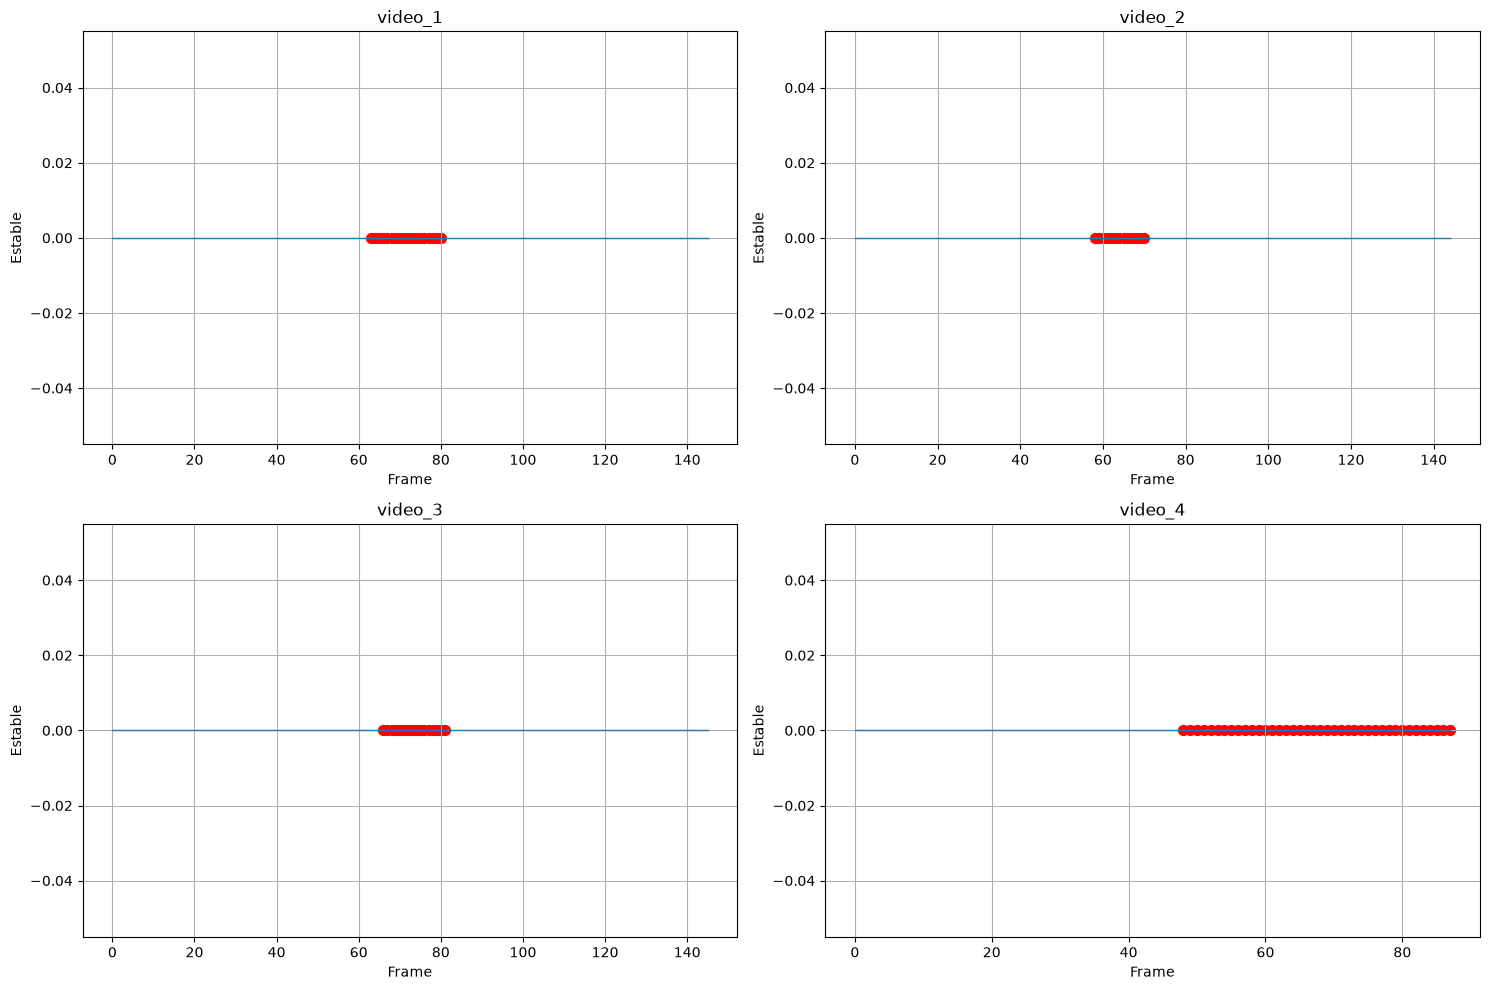

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))
axes = axes.ravel()

for idx, (key, movimiento) in enumerate(movimiento_centroides_por_video.items()):
  ax = axes[idx]
  total_frames = len(videos_data[key]['frames'])
  ax.plot(np.arange(total_frames), np.zeros(total_frames), linewidth=1)
  frames_estables = frames_estables_por_video[key]
  ax.scatter(frames_estables, np.zeros(len(frames_estables)), s=50, color='red')
  ax.set_title(key)
  ax.set_xlabel("Frame")
  ax.set_ylabel("Estable")
  ax.grid(True)

plt.tight_layout()
plt.show()

In [7]:
for key, frames_estables in frames_estables_por_video.items():
  print(f"{key}: "f"{len(frames_estables)} frames estables")
  print(frames_estables)

video_1: 18 frames estables
[63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80]
video_2: 13 frames estables
[58 59 60 61 62 63 64 65 66 67 68 69 70]
video_3: 16 frames estables
[66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81]
video_4: 40 frames estables
[48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87]


In [8]:
for key, frames_estables in frames_estables_por_video.items():
  if len(frames_estables) > 0:
    inicio = frames_estables[0]
    fin = frames_estables[-1]
    print(f"{key}: "f"estable desde frame {inicio} hasta {fin}")

video_1: estable desde frame 63 hasta 80
video_2: estable desde frame 58 hasta 70
video_3: estable desde frame 66 hasta 81
video_4: estable desde frame 48 hasta 87


## B. Deteccion de Valores de Dados

### Crop de Dados

In [9]:
for key, data in videos_data.items():
  crops = []
  for idx_frame in data["frames_estables"]:
    frame = data["frames"][idx_frame]
    boxes, _ = detectar_dados(frame)
    if len(boxes) != 5:
      continue
    for dado_id, (x, y, w, h) in enumerate(boxes):
      crop = frame[y:y+h, x:x+w]
      crops.append({
        "frame": idx_frame,
        "dado": dado_id,
        "crop": crop
      })

  videos_data[key]["crops_dados"] = crops

### Deteccion del Valor del Dado

In [10]:
def detectar_valor_dado(crop):
  MARGEN = 8
  hsv = cv2.cvtColor(crop, cv2.COLOR_BGR2HSV)
  _, s, _ = cv2.split(hsv)
  _, mask = cv2.threshold(s, 80, 255, cv2.THRESH_BINARY_INV)
  kernel = np.ones((3, 3), np.uint8)
  mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
  num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
  cantidad_puntos = 0
  alto, ancho = mask.shape
  for i in range(1, num_labels):
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    area = stats[i, cv2.CC_STAT_AREA]
    aspect_ratio = w / h
    fill_ratio = area / (w * h)
    toca_borde = (
      x < MARGEN or
      y < MARGEN or
      x + w > ancho - MARGEN or
      y + h > alto - MARGEN
    )
    es_punto = (
      50 < area < 300
      and 0.6 < aspect_ratio < 1.6
      and fill_ratio > 0.35
      and not toca_borde
    )

    if es_punto:
      cantidad_puntos += 1

  return cantidad_puntos

In [11]:
resultados_videos = {}
for key, data in videos_data.items():
  resultados_frames = {}
  frame_ref = data["frames"][data["frames_estables"][0]]
  boxes_fijas, _ = detectar_dados(frame_ref)
  if len(boxes) != 5:
    continue
  valores_fijos = []
  for (x, y, w, h) in boxes_fijas:
    crop = frame_ref[y:y+h, x:x+w]
    valor = detectar_valor_dado(crop)
    valores_fijos.append(valor)
  for frame_idx in data["frames_estables"]:
    resultados_frames[frame_idx] = {"boxes": boxes_fijas, "valores": valores_fijos}
  resultados_videos[key] = resultados_frames

### Graficos

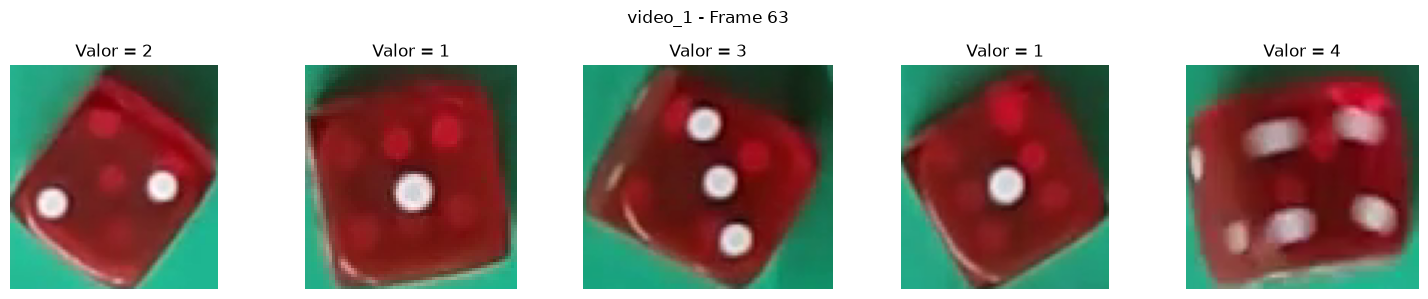

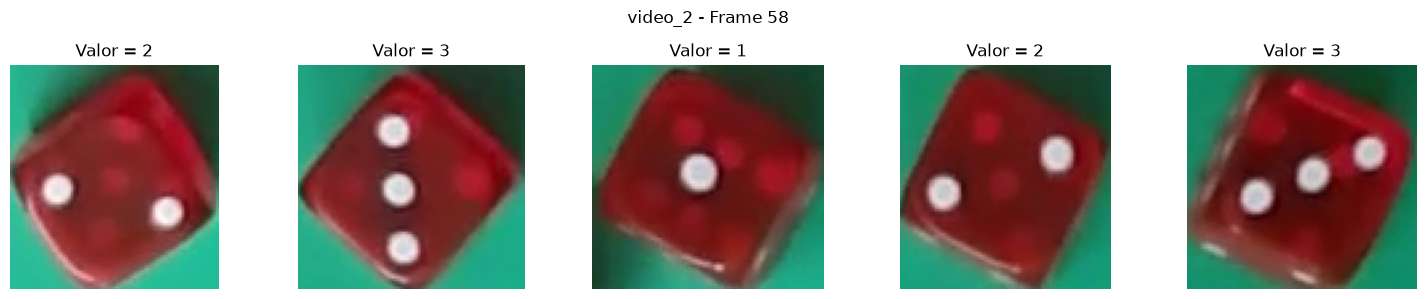

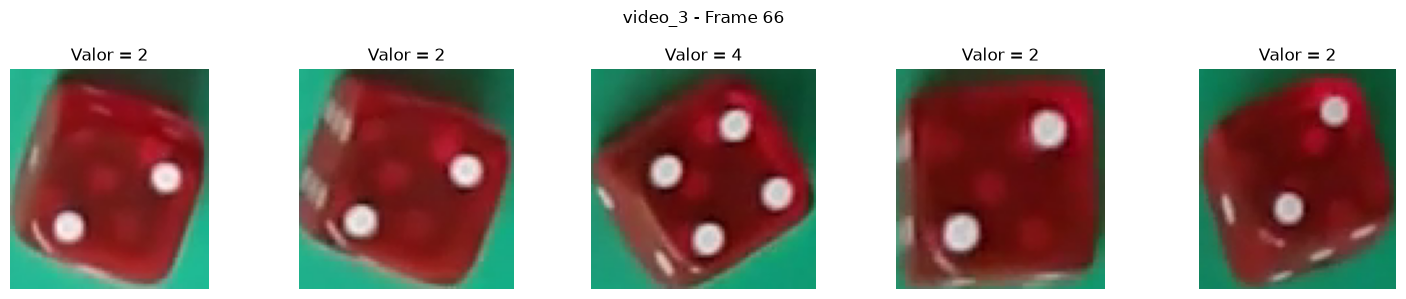

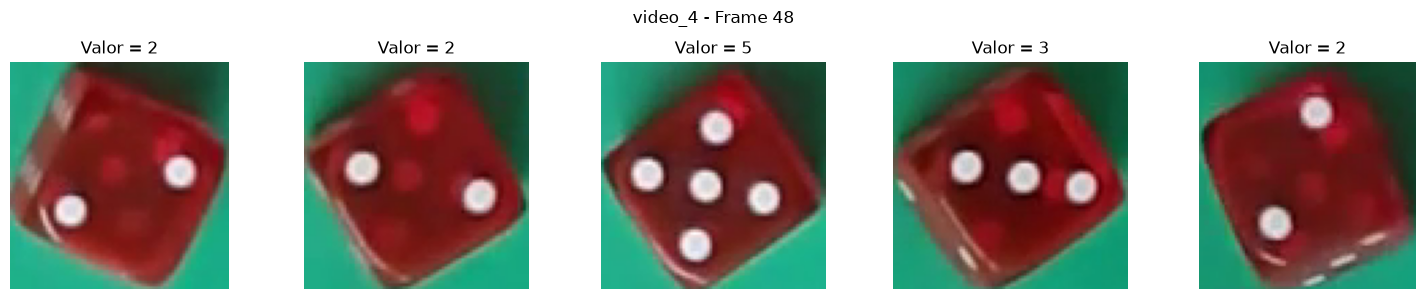

In [12]:
for key, data in videos_data.items():

    frame_idx = data["frames_estables"][0]

    frame = data["frames"][frame_idx]

    boxes, _ = detectar_dados(frame)

    fig, axes = plt.subplots(1, 5, figsize=(15, 3))

    for ax, (x, y, w, h) in zip(axes, boxes):

        crop = frame[y:y+h, x:x+w]

        valor = detectar_valor_dado(crop)

        ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Valor = {valor}")
        ax.axis("off")

    plt.suptitle(f"{key} - Frame {frame_idx}")
    plt.tight_layout()
    plt.show()

## C. Generación de Videos Resultantes

### Generar video final

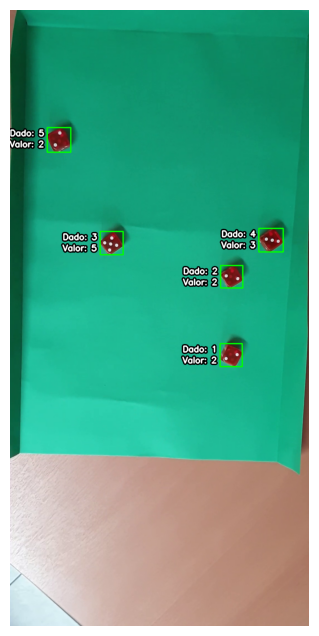

In [14]:
video = "video_4"
frame_idx = next(iter(resultados_videos[video]))
frame = videos_data[video]["frames"][frame_idx].copy()
info = resultados_videos[video][frame_idx]
for i, ((x, y, w, h), valor) in enumerate(zip(info["boxes"], info["valores"])):
  texto1 = f"Dado: {i+1}"
  texto2 = f"Valor: {valor}"
  x_text = x
  y_text = y - 10
  cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 3)
  cv2.putText(frame, texto1, (x_text - 135, y_text + 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,0), 13)
  cv2.putText(frame, texto1, (x_text - 135, y_text + 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 4)
  cv2.putText(frame, texto2, (x_text - 135, y_text + 80), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,0), 13)
  cv2.putText(frame, texto2, (x_text - 135, y_text + 80), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 4)
  
plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [15]:
for key, data in videos_data.items():
  alto, ancho = data["frames"][0].shape[:2]
  out = cv2.VideoWriter(f"output_{key}.mp4", cv2.VideoWriter_fourcc(*"mp4v"), data["fps"], (ancho, alto))
  for idx, frame in enumerate(data["frames"]):
    frame_out = frame.copy()
    if idx in resultados_videos[key]:
      info = resultados_videos[key][idx]
      boxes = info["boxes"]
      valores = info["valores"]
      for i, ((x, y, w_box, h_box), valor) in enumerate(zip(boxes, valores)):
        texto1 = f"Dado: {i+1}"
        texto2 = f"Valor: {valor}"
        x_text = x
        y_text = y - 10
        cv2.rectangle(frame_out, (x, y), (x+w_box, y+h_box), (0,255,0), 3)
        cv2.putText(frame_out, texto1, (x_text - 135, y_text + 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,0), 13)
        cv2.putText(frame_out, texto1, (x_text - 135, y_text + 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 4)
        cv2.putText(frame_out, texto2, (x_text - 135, y_text + 80), cv2.FONT_HERSHEY_SIMPLEX, 1, (0,0,0), 13)
        cv2.putText(frame_out, texto2, (x_text - 135, y_text + 80), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 4)
    out.write(frame_out)
  out.release()
  print(f"{key} exportado")
  out.release()
cv2.destroyAllWindows()

video_1 exportado
video_2 exportado
video_3 exportado
video_4 exportado
